In [2]:
import numpy as np
import mat73
import matplotlib.pyplot as plt

from shapely.geometry import Point, MultiPoint, Polygon
from shapely.ops import unary_union
from shapely.prepared import prep

# --- load data ---
data = mat73.loadmat("/unity/g2/jmiranda/SubsurfaceFields/Data/ARGO_GoM_20220920.mat")
LAT = np.asarray(data["LAT"]).ravel()
LON = np.asarray(data["LON"]).ravel()

# --- build a 0.125°-resolved boundary of the cloud ---
# Buffer every point by 0.125°, union, and clean topology. (join_style=2 -> miter corners)
buf_r = 0.25
# If memory is tight, chunk the union; otherwise this one-liner is fine:
region = MultiPoint(np.c_[LON, LAT]).buffer(buf_r, resolution=8, join_style=2).buffer(0)

# # fill all interior void
# def outer_shell(geom):
#     if geom.geom_type == "Polygon":
#         return Polygon(geom.exterior)
#     elif geom.geom_type == "MultiPolygon":
#         return unary_union([Polygon(p.exterior) for p in geom.geoms])
#     return geom

# region_filled = outer_shell(region)

region_prep = prep(region)  # speeds up many contains() calls

# --- make a regular 0.25° grid over the bbox of the cloud (with a little padding) ---
step = 0.25
pad  = buf_r
lon_min, lon_max = LON.min() - pad, LON.max() + pad
lat_min, lat_max = LAT.min() - pad, LAT.max() + pad

# snap to exact 0.25° ticks
lon_ticks = np.arange(np.floor(lon_min/step)*step, np.ceil(lon_max/step)*step + 1e-12, step)
lat_ticks = np.arange(np.floor(lat_min/step)*step, np.ceil(lat_max/step)*step + 1e-12, step)
XX, YY = np.meshgrid(lon_ticks, lat_ticks)

# --- pick grid points inside the buffered cloud ---
lon_grid = XX.ravel()
lat_grid = YY.ravel()
inside_mask = np.fromiter(
    (region_prep.contains(Point(x, y)) for x, y in zip(lon_grid, lat_grid)),
    dtype=bool,
    count=lon_grid.size
)

lon_in = lon_grid[inside_mask]
lat_in = lat_grid[inside_mask]




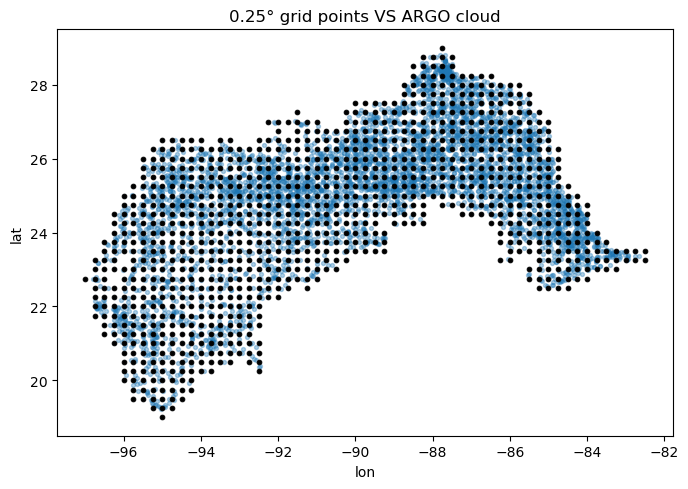

In [24]:

plt.figure(figsize=(7,5))
plt.scatter(LON, LAT, s=8, alpha=0.35)
plt.scatter(lon_in, lat_in, s=12, color='k', linewidths=0.6)
plt.title("0.25° grid points VS ARGO cloud")
plt.xlabel("lon"); plt.ylabel("lat"); plt.tight_layout(); plt.show()

In [15]:
#export lon_grid, lat_grid and inside_mask in a pickle file
import pickle

data = {
    "lon_grid": lon_grid,
    "lat_grid": lat_grid,
    "inside_mask": inside_mask
}

with open("nespreso_grid_and_mask.pkl", "wb") as f:
    pickle.dump(data, f)




In [5]:
import pickle
#test loading the pickle file
with open("/unity/g2/jmiranda/nespreso_api/data/nespreso_grid_and_mask.pkl", "rb") as f:
    data = pickle.load(f)

lon_grid = data["lon_grid"]
lat_grid = data["lat_grid"]
inside_mask = data["inside_mask"]

print(f"Original data shape: {lon_grid.shape}")
print(f"Mask sum: {inside_mask.sum()}")

Original data shape: (2623,)
Mask sum: 1018


In [6]:
import numpy as np
# Reshape grid to 2D to check neighbors
lon_unique = np.unique(lon_grid)
lat_unique = np.unique(lat_grid)
n_lon = len(lon_unique)
n_lat = len(lat_unique)

# Create 2D arrays
lon_2d = lon_grid.reshape(n_lat, n_lon)
lat_2d = lat_grid.reshape(n_lat, n_lon)
mask_2d = inside_mask.reshape(n_lat, n_lon)

# Include masked out grid points that have less than two masked out immediate neighbors
# (check only x and y neighbors, ignore diagonals)
updated_mask_2d = mask_2d.copy()

for i in range(n_lat):
    for j in range(n_lon):
        if not mask_2d[i, j]:  # If point is masked out
            # Count masked out neighbors in x and y (not diagonals)
            masked_neighbors = 0
            
            # Check left neighbor
            if j > 0 and not mask_2d[i, j-1]:
                masked_neighbors += 1
            # Check right neighbor
            if j < n_lon - 1 and not mask_2d[i, j+1]:
                masked_neighbors += 1
            # Check bottom neighbor
            if i > 0 and not mask_2d[i-1, j]:
                masked_neighbors += 1
            # Check top neighbor
            if i < n_lat - 1 and not mask_2d[i+1, j]:
                masked_neighbors += 1
            
            # If less than 2 masked neighbors, include this point
            if masked_neighbors < 2:
                updated_mask_2d[i, j] = True

# Flatten back to 1D
updated_mask = updated_mask_2d.ravel()
lon_grid_updated = lon_grid[updated_mask]
lat_grid_updated = lat_grid[updated_mask]

print(f"Updated mask sum: {updated_mask.sum()}")
print(f"Points added: {updated_mask.sum() - inside_mask.sum()}")


Updated mask sum: 1030
Points added: 12


In [7]:
# Update lat and lon grid to start and end with only zeros in the decimals
# Use floor for min and ceil for max
lon_min = np.floor(lon_grid_updated.min())
lon_max = np.ceil(lon_grid_updated.max())
lat_min = np.floor(lat_grid_updated.min())
lat_max = np.ceil(lat_grid_updated.max())

print(f"Original lon range: [{lon_grid_updated.min():.2f}, {lon_grid_updated.max():.2f}]")
print(f"Updated lon range: [{lon_min:.2f}, {lon_max:.2f}]")
print(f"Original lat range: [{lat_grid_updated.min():.2f}, {lat_grid_updated.max():.2f}]")
print(f"Updated lat range: [{lat_min:.2f}, {lat_max:.2f}]")

# Recreate grid with updated bounds
step = 0.25
lon_ticks_updated = np.arange(lon_min, lon_max + 1e-12, step)
lat_ticks_updated = np.arange(lat_min, lat_max + 1e-12, step)
XX_updated, YY_updated = np.meshgrid(lon_ticks_updated, lat_ticks_updated)

lon_grid_final = XX_updated.ravel()
lat_grid_final = YY_updated.ravel()

# Create mask for the new grid based on updated_mask
# Map old grid points to new grid
# Find which points in the new grid correspond to points in the old updated grid
# Use a small tolerance for floating point comparison
tolerance = 1e-6
mask_final = np.zeros(len(lon_grid_final), dtype=bool)

for i, (lon_new, lat_new) in enumerate(zip(lon_grid_final, lat_grid_final)):
    # Check if this point exists in the updated grid
    matches = (np.abs(lon_grid_updated - lon_new) < tolerance) & (np.abs(lat_grid_updated - lat_new) < tolerance)
    if np.any(matches):
        mask_final[i] = True

print(f"Final grid size: {len(lon_grid_final)}")
print(f"Final mask sum: {mask_final.sum()}")


Original lon range: [-97.00, -82.50]
Updated lon range: [-97.00, -82.00]
Original lat range: [19.00, 29.00]
Updated lat range: [19.00, 29.00]
Final grid size: 2501
Final mask sum: 1030


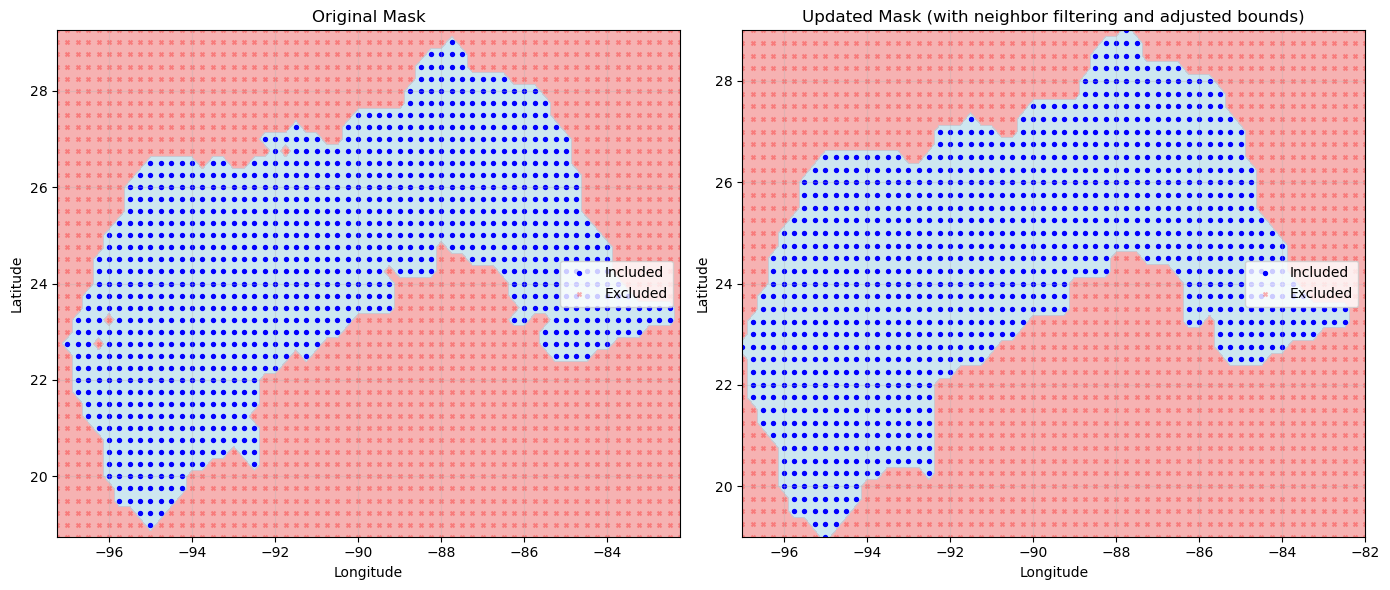

Visualization saved as 'nespreso_mask_visualization.png'


In [8]:
# Visualize the mask and grid
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Original mask
lon_2d_orig = lon_grid.reshape(n_lat, n_lon)
lat_2d_orig = lat_grid.reshape(n_lat, n_lon)
mask_2d_orig = inside_mask.reshape(n_lat, n_lon)

ax1 = axes[0]
im1 = ax1.contourf(lon_2d_orig, lat_2d_orig, mask_2d_orig.astype(int), levels=[0, 0.5, 1], colors=['lightcoral', 'lightblue'], alpha=0.6)
ax1.scatter(lon_grid[inside_mask], lat_grid[inside_mask], s=8, color='blue', marker='o', label='Included')
ax1.scatter(lon_grid[~inside_mask], lat_grid[~inside_mask], s=8, color='red', marker='x', alpha=0.3, label='Excluded')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Original Mask')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Updated mask
n_lat_final = len(lat_ticks_updated)
n_lon_final = len(lon_ticks_updated)
lon_2d_final = lon_grid_final.reshape(n_lat_final, n_lon_final)
lat_2d_final = lat_grid_final.reshape(n_lat_final, n_lon_final)
mask_2d_final = mask_final.reshape(n_lat_final, n_lon_final)

ax2 = axes[1]
im2 = ax2.contourf(lon_2d_final, lat_2d_final, mask_2d_final.astype(int), levels=[0, 0.5, 1], colors=['lightcoral', 'lightblue'], alpha=0.6)
ax2.scatter(lon_grid_final[mask_final], lat_grid_final[mask_final], s=8, color='blue', marker='o', label='Included')
ax2.scatter(lon_grid_final[~mask_final], lat_grid_final[~mask_final], s=8, color='red', marker='x', alpha=0.3, label='Excluded')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Updated Mask (with neighbor filtering and adjusted bounds)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nespreso_mask_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Visualization saved as 'nespreso_mask_visualization.png'")


In [9]:
# Save the updated grid and mask (override the original)
data_updated = {
    "lon_grid": lon_grid_final,
    "lat_grid": lat_grid_final,
    "inside_mask": mask_final
}

# Save to the data directory (override the original)
output_path = "/unity/g2/jmiranda/nespreso_api/data/nespreso_grid_and_mask.pkl"
with open(output_path, "wb") as f:
    pickle.dump(data_updated, f)

print(f"Updated grid and mask saved to {output_path}")
print(f"Final grid size: {len(lon_grid_final)}")
print(f"Final mask sum: {mask_final.sum()} ({100*mask_final.sum()/len(mask_final):.1f}% included)")


Updated grid and mask saved to /unity/g2/jmiranda/nespreso_api/data/nespreso_grid_and_mask.pkl
Final grid size: 2501
Final mask sum: 1030 (41.2% included)
